# What an early matter-dominated era does to axion productionPyBolt solves against a pluggable expansion history. The default, `StandardCosmology`,is radiation domination with a conserved comoving entropy. This notebook compares itagainst the two reheating backgrounds, and shows where the differences in the yieldsand in the final distributions actually come from.The three backgrounds:| | ||---|---|| `StandardCosmology` | radiation domination, $s a^3$ conserved || `SuddenDecayReheating` | piecewise analytic: $H \propto T^4$, $w = 3/8$ above $T_{rh}$, hard switch below || `PerturbativeReheating` | the same scenario integrated as a two-fluid system, transition resolved |Both reheating tiers take the same $T_{rh}$ and therefore the same$\Gamma = 3 H_{rad}(T_{rh})$, so they are directly comparable.**Runtime.** The yield scans use the number-density equation and take seconds. Thedistributions use the full phase-space equation and are slow -- about 70 s for thestandard background but around 350 s for each reheating one, since the much largermomentum-redshift term stiffens the system. Budget roughly 25 minutes for a cold run.They are cached to `notebook_cache/`; delete that directory to force a recompute.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np

from PyBolt import boltzmann_solver as bz

from PyBolt.background import (
    PerturbativeReheating,
    StandardCosmology,
    SuddenDecayReheating,
)
from PyBolt.processes import LeptonAnnihilationToAxionMB, PrimakoffScatteringMB

import fBE_LFC

M_MU, G_MU = fBE_LFC.lepton_properties("muon")
RATIO = 1000.0
T_START = RATIO * M_MU        # GeV, where the run begins
F_A = 1.0e7                   # GeV, axion decay constant for the single-value plots

print("muon mass  {:.5f} GeV".format(M_MU))
print("T_start    {:.4f} GeV".format(T_START))

/home/agomulka/.venvs/pybolt/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


muon mass  0.10565 GeV
T_start    105.6500 GeV


## 1. The backgrounds themselvesEverything downstream follows from these three curves, so it is worth looking at thembefore looking at any axion.`w` is $-d\ln T/d\ln a$. It is $\approx 1$ in radiation domination (the plasma cools as$a^{-1}$, up to the dof features that make it $1/(1+\tilde g)$), and $3/8$ duringreheating, because the bath is being replenished as fast as it redshifts.

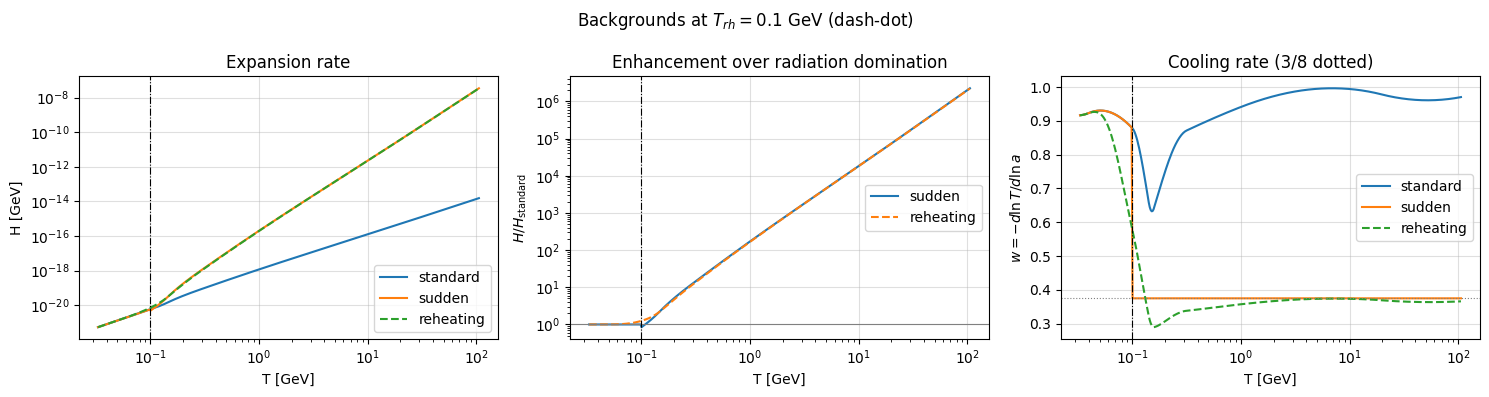

In [2]:
T_RH_SHOWN = 0.1  # GeV

std = StandardCosmology()
sud = SuddenDecayReheating(T_rh=T_RH_SHOWN)
reh = PerturbativeReheating(T_rh=T_RH_SHOWN, T_start=T_START)

# Stay inside the range the numerical background integrated.
T = np.logspace(np.log10(reh.T_range[0] * 1.01), np.log10(T_START), 400)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].loglog(T, std.H(T), label="standard")
axes[0].loglog(T, sud.H(T), label="sudden")
axes[0].loglog(T, reh.H(T), "--", label="reheating")
axes[0].set_xlabel("T [GeV]")
axes[0].set_ylabel("H [GeV]")
axes[0].set_title("Expansion rate")

axes[1].loglog(T, sud.H(T) / std.H(T), label="sudden")
axes[1].loglog(T, reh.H(T) / std.H(T), "--", label="reheating")
axes[1].axhline(1.0, color="grey", lw=0.8)
axes[1].set_xlabel("T [GeV]")
axes[1].set_ylabel(r"$H / H_{\rm standard}$")
axes[1].set_title("Enhancement over radiation domination")

axes[2].semilogx(T, std.w(T), label="standard")
axes[2].semilogx(T, sud.w(T), label="sudden")
axes[2].semilogx(T, reh.w(T), "--", label="reheating")
axes[2].axhline(3.0 / 8.0, color="grey", lw=0.8, ls=":")
axes[2].set_xlabel("T [GeV]")
axes[2].set_ylabel(r"$w = -d\ln T / d\ln a$")
axes[2].set_title("Cooling rate (3/8 dotted)")

for ax in axes:
    ax.axvline(T_RH_SHOWN, color="k", lw=0.8, ls="-.")
    ax.grid(alpha=0.4)
    ax.legend()

fig.suptitle(r"Backgrounds at $T_{{rh}} = {} $ GeV (dash-dot)".format(T_RH_SHOWN))
fig.tight_layout()
plt.show()

The enhancement reaches $10^6$ by the top of the range, which is the whole point of thescenario. On that scale the two tiers look identical; the differences live near$T_{rh}$ and need a zoom.Note already in the right panel that `sudden` sits flat at exactly $3/8$ above$T_{rh}$, while `reheating` dips well below it around $T \sim 0.15$ GeV. That is theQCD transition: entropy dumped out of the quark-gluon dof slows the cooling further,which the analytic $w = 3/8$ cannot know about. The standard background shows the samefeature, as the dip to $w \approx 0.63$.

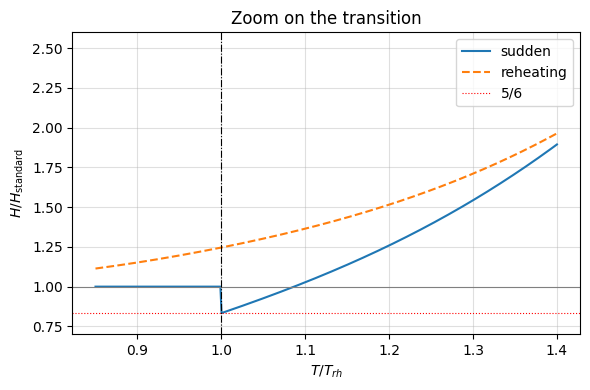

In [3]:
# A tight window: the T^4 growth swamps the step within half a decade.
T_zoom = np.linspace(0.85 * T_RH_SHOWN, 1.4 * T_RH_SHOWN, 400)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(T_zoom / T_RH_SHOWN, sud.H(T_zoom) / std.H(T_zoom), label="sudden")
ax.plot(T_zoom / T_RH_SHOWN, reh.H(T_zoom) / std.H(T_zoom), "--", label="reheating")
ax.axhline(1.0, color="grey", lw=0.8)
ax.axhline(5.0 / 6.0, color="red", lw=0.8, ls=":", label="5/6")
ax.axvline(1.0, color="k", lw=0.8, ls="-.")
ax.set_xlabel(r"$T / T_{rh}$")
ax.set_ylabel(r"$H / H_{\rm standard}$")
ax.set_ylim(0.7, 2.6)
ax.set_title("Zoom on the transition")
ax.grid(alpha=0.4)
ax.legend()
fig.tight_layout()
plt.show()

Now the artefact of the cheap background is visible: `sudden` drops discontinuously toexactly $5/6$ the moment it crosses $T_{rh}$, so its expansion is briefly *slower* thanradiation domination before the $T^4$ growth takes over. That happens because$\Gamma = 3 H_{rad}(T_{rh})$ is a convention, not a matching condition — the step is$5/6$ regardless of $T_{rh}$ or $g_\rho$. `reheating` crosses smoothly.The other difference is on the left of the dash-dot line. `sudden` is *exactly*radiation domination below $T_{rh}$, by construction. `reheating` is still about 10%faster there, because the inflaton does not stop decaying at $T_{rh}$ — thattemperature is just where $\Gamma$ was defined. The residual energy takes anothere-fold or so to drain away, and the numerical background carries it.Two consequences feed the Boltzmann equations, and they are worth separating becausethey act on different things.

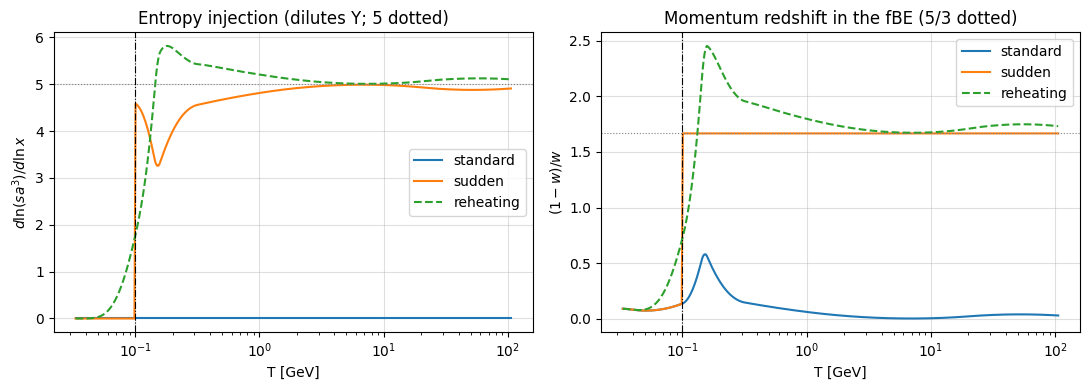

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].semilogx(T, std.dln_sa3_dlnx(T), label="standard")
axes[0].semilogx(T, sud.dln_sa3_dlnx(T), label="sudden")
axes[0].semilogx(T, reh.dln_sa3_dlnx(T), "--", label="reheating")
axes[0].axhline(5.0, color="grey", lw=0.8, ls=":")
axes[0].set_ylabel(r"$d\ln(s a^3) / d\ln x$")
axes[0].set_title("Entropy injection (dilutes Y; 5 dotted)")

axes[1].semilogx(T, std.redshift_coeff(T), label="standard")
axes[1].semilogx(T, sud.redshift_coeff(T), label="sudden")
axes[1].semilogx(T, reh.redshift_coeff(T), "--", label="reheating")
axes[1].axhline(5.0 / 3.0, color="grey", lw=0.8, ls=":")
axes[1].set_ylabel(r"$(1-w)/w$")
axes[1].set_title("Momentum redshift in the fBE (5/3 dotted)")

for ax in axes:
    ax.axvline(T_RH_SHOWN, color="k", lw=0.8, ls="-.")
    ax.set_xlabel("T [GeV]")
    ax.grid(alpha=0.4)
    ax.legend()

fig.tight_layout()
plt.show()

**Left: entropy injection.** Zero on the standard background by construction, and $5$during reheating ($3/w - 3$ with $w=3/8$). This is a pure dilution of $Y = n/s$: itsuppresses the yield without touching the spectral shape.**Right: the momentum-redshift coefficient** $(1-w)/w$, which multiplies$(q\,\partial_q f - 2f)$ in the phase-space equation. Normally this is $\tilde g$,a small number between $0$ and $\sim0.3$, so $q = p/T$ is very nearly frozen: $p$ and$T$ both fall as $a^{-1}$ and the ratio does not move. During reheating the coefficientis $5/3$ — larger by an order of magnitude — because $T$ falls more slowly than$a^{-1}$, so momenta fall *relative to the bath* and each mode's $q$ is dragged down.So the two effects act on different things: dilution changes the normalisation of $Y$,while the redshift term is the only one that can change the shape of $f(q)$. Sections 2and 3 look at them in turn — though section 3 shows that the shape is not decided bythis term alone.

## 2. YieldsThe number-density equation is cheap, so this scans $T_{rh}$ properly. The effect isset by where $T_{rh}$ sits relative to the production epoch, which for a muon run peaksnear $T \sim m_\mu = 0.106$ GeV.

In [5]:
def solve_yield(background):
    '''Final comoving abundance Y from the number-density equation.'''
    x = np.linspace(M_MU / T_START, 30.0, 500)
    q = np.linspace(1e-2, 20.0, 250)

    model = bz.Model(M_MU, 1e-10, 1.0, "b", background=background)
    model.changeGrid(x, q)

    ann = LeptonAnnihilationToAxionMB(M_MU, G_MU, 1.0 / F_A, False)
    pri = PrimakoffScatteringMB(M_MU, G_MU, 1.0 / F_A, False)

    Y = model.solve_nBE(x, lambda x_, Y_: ann.rate(x_, Y_) + pri.rate(x_, Y_), 0.0)
    return Y[-1]


T_RH_SCAN = np.array([50.0, 10.0, 3.0, 1.0, 0.3, 0.1, 0.03, 0.01, 0.006])

Y_std = solve_yield(std)
Y_sud = np.array([solve_yield(SuddenDecayReheating(T_rh=t)) for t in T_RH_SCAN])
Y_reh = np.array([
    solve_yield(PerturbativeReheating(T_rh=t, T_start=T_START)) for t in T_RH_SCAN
])

print("standard RD:  Y = {:.5e}".format(Y_std))

2026-09-04 00:27:49,970 - Starting solve_nBE...
/mnt/e/Workplace/_Projects/pybolt/PyBolt/PyBolt/cosmology.py:106: RuntimeWarning: overflow encountered in exp
  integral, _ = quad(lambda t: np.sqrt(t**2 - x**2)*t/(np.exp(t)+1.0),x,np.inf)
2026-09-04 00:27:50,809 - solve_nBE completed in 0.84 seconds
2026-09-04 00:27:50,810 - Starting solve_nBE...
2026-09-04 00:27:51,733 - solve_nBE completed in 0.92 seconds
2026-09-04 00:27:51,734 - Starting solve_nBE...
2026-09-04 00:27:52,735 - Progress: 5.075337061217466/30.0, 16.92% - Elapsed time: 1.00 seconds
2026-09-04 00:27:52,817 - solve_nBE completed in 1.08 seconds
2026-09-04 00:27:52,818 - Starting solve_nBE...
2026-09-04 00:27:53,820 - Progress: 3.8705081508207644/30.0, 12.90% - Elapsed time: 1.00 seconds
2026-09-04 00:27:53,937 - solve_nBE completed in 1.12 seconds
2026-09-04 00:27:53,938 - Starting solve_nBE...
2026-09-04 00:27:54,938 - Progress: 5.796806912023012/30.0, 19.32% - Elapsed time: 1.00 seconds
2026-09-04 00:27:55,003 - solve_n

standard RD:  Y = 8.68315e-03


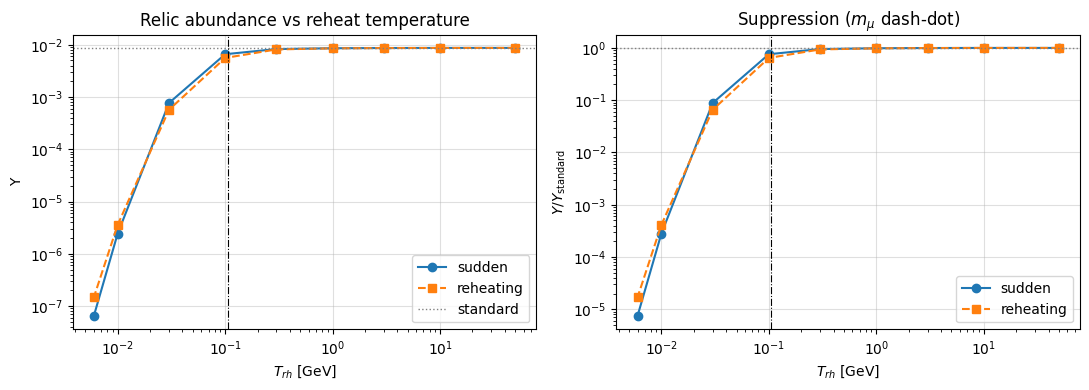

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].loglog(T_RH_SCAN, Y_sud, "o-", label="sudden")
axes[0].loglog(T_RH_SCAN, Y_reh, "s--", label="reheating")
axes[0].axhline(Y_std, color="grey", lw=1.0, ls=":", label="standard")
axes[0].axvline(M_MU, color="k", lw=0.8, ls="-.")
axes[0].set_ylabel("Y")
axes[0].set_title("Relic abundance vs reheat temperature")

axes[1].semilogx(T_RH_SCAN, Y_sud / Y_std, "o-", label="sudden")
axes[1].semilogx(T_RH_SCAN, Y_reh / Y_std, "s--", label="reheating")
axes[1].axhline(1.0, color="grey", lw=1.0, ls=":")
axes[1].axvline(M_MU, color="k", lw=0.8, ls="-.")
axes[1].set_yscale("log")
axes[1].set_ylabel(r"$Y / Y_{\rm standard}$")
axes[1].set_title(r"Suppression ($m_\mu$ dash-dot)")

for ax in axes:
    ax.set_xlabel(r"$T_{rh}$ [GeV]")
    ax.grid(alpha=0.4)
    ax.legend()

fig.tight_layout()
plt.show()

In [7]:
print("{:>10} {:>14} {:>14} {:>10} {:>10} {:>10}".format(
    "T_rh[GeV]", "Y_sudden", "Y_reheating", "sud/std", "reh/std", "sud/reh"))
for t, ys, yr in zip(T_RH_SCAN, Y_sud, Y_reh):
    print("{:>10} {:>14.5e} {:>14.5e} {:>10.4f} {:>10.4f} {:>10.4f}".format(
        t, ys, yr, ys / Y_std, yr / Y_std, ys / yr))

 T_rh[GeV]       Y_sudden    Y_reheating    sud/std    reh/std    sud/reh
      50.0    8.68319e-03    8.68317e-03     1.0000     1.0000     1.0000
      10.0    8.68017e-03    8.67529e-03     0.9997     0.9991     1.0006
       3.0    8.64484e-03    8.63134e-03     0.9956     0.9940     1.0016
       1.0    8.56391e-03    8.52783e-03     0.9863     0.9821     1.0042
       0.3    8.26586e-03    8.13521e-03     0.9519     0.9369     1.0161
       0.1    6.58272e-03    5.58721e-03     0.7581     0.6435     1.1782
      0.03    7.66492e-04    5.68902e-04     0.0883     0.0655     1.3473
      0.01    2.43769e-06    3.57090e-06     0.0003     0.0004     0.6827
     0.006    6.46687e-08    1.46889e-07     0.0000     0.0000     0.4403


Nothing moves while $T_{rh}$ is well above $m_\mu$: reheating is over before the axionsare made. Once $T_{rh}$ drops into the production epoch the yield collapses, by fourorders of magnitude by the time $T_{rh}$ reaches the BBN floor near 5 MeV.The last column is the one to watch. The cheap background is good to a fraction of apercent while the effect is small, and wrong by tens of percent exactly where theeffect is large — and the sign of its error flips. Use `sudden` to find the interestingregion and `reheating` to quote a number.

## 2b. Against instantaneous reheatingSection 2 compares against a universe with no reheating era at all, starting at$T_{start} = 105.65$ GeV. That isolates what the background does, but it is not thecomparison most of the literature makes.The usual treatment is **instantaneous reheating**: assume the universe is simplyradiation dominated from $T_{rh}$ downwards, with an empty axion population at$T_{rh}$ and nothing before it. PyBolt has always been able to do this, and needs nonew code — it is exactly a standard-background run whose integration *starts* at$T_{rh}$. That is what the old `T_reh` name meant.So the honest question is: at the **same** $T_{rh}$, how good is instantaneous?

In [8]:
def instantaneous_yield(T_rh):
    '''Old picture: RD from T_rh down, empty at T_rh, nothing before.'''
    return solve_yield_from(StandardCosmology(), T_rh)


def solve_yield_from(background, T_begin):
    '''Final Y for a run that starts at T_begin rather than at T_START.'''
    x = np.linspace(M_MU / T_begin, 30.0, 500)
    q = np.linspace(1e-2, 20.0, 250)

    model = bz.Model(M_MU, 1e-10, 1.0, "b", background=background)
    model.changeGrid(x, q)

    ann = LeptonAnnihilationToAxionMB(M_MU, G_MU, 1.0 / F_A, False)
    pri = PrimakoffScatteringMB(M_MU, G_MU, 1.0 / F_A, False)
    return model.solve_nBE(
        x, lambda x_, Y_: ann.rate(x_, Y_) + pri.rate(x_, Y_), 0.0)[-1]


T_RH_CMP = np.array([3.0, 1.0, 0.3, 0.1, 0.03, 0.01])

Y_inst = np.array([instantaneous_yield(t) for t in T_RH_CMP])
Y_sud_c = np.array([
    solve_yield_from(SuddenDecayReheating(T_rh=t), T_START) for t in T_RH_CMP])
Y_reh_c = np.array([
    solve_yield_from(PerturbativeReheating(T_rh=t, T_start=T_START), T_START)
    for t in T_RH_CMP])

print("{:>9} {:>9} {:>13} {:>13} {:>10} {:>10}".format(
    "T_rh", "x_start", "Y_instant", "Y_reheating", "sud/inst", "reh/inst"))
for t, yi, ys, yr in zip(T_RH_CMP, Y_inst, Y_sud_c, Y_reh_c):
    print("{:>9} {:>9.3f} {:>13.5e} {:>13.5e} {:>10.4f} {:>10.4f}".format(
        t, M_MU / t, yi, yr, ys / yi, yr / yi))

2026-09-04 00:28:09,598 - Starting solve_nBE...
2026-09-04 00:28:10,338 - solve_nBE completed in 0.74 seconds
2026-09-04 00:28:10,338 - Starting solve_nBE...
2026-09-04 00:28:11,081 - solve_nBE completed in 0.74 seconds
2026-09-04 00:28:11,082 - Starting solve_nBE...
2026-09-04 00:28:11,750 - solve_nBE completed in 0.67 seconds
2026-09-04 00:28:11,751 - Starting solve_nBE...
2026-09-04 00:28:12,156 - solve_nBE completed in 0.40 seconds
2026-09-04 00:28:12,157 - Starting solve_nBE...
2026-09-04 00:28:12,333 - solve_nBE completed in 0.18 seconds
2026-09-04 00:28:12,334 - Starting solve_nBE...
2026-09-04 00:28:12,391 - solve_nBE completed in 0.06 seconds
2026-09-04 00:28:12,392 - Starting solve_nBE...
2026-09-04 00:28:13,392 - Progress: 4.133487328572886/30.0, 13.78% - Elapsed time: 1.00 seconds
2026-09-04 00:28:13,493 - solve_nBE completed in 1.10 seconds
2026-09-04 00:28:13,494 - Starting solve_nBE...
2026-09-04 00:28:14,495 - Progress: 3.950425270238536/30.0, 13.17% - Elapsed time: 1.0

     T_rh   x_start     Y_instant   Y_reheating   sud/inst   reh/inst
      3.0     0.035   8.61867e-03   8.63134e-03     1.0030     1.0015
      1.0     0.106   8.49455e-03   8.52783e-03     1.0082     1.0039
      0.3     0.352   8.00255e-03   8.13521e-03     1.0329     1.0166
      0.1     1.056   4.60635e-03   5.58721e-03     1.4291     1.2129
     0.03     3.522   1.62525e-04   5.68902e-04     4.7162     3.5004
     0.01    10.565   1.85603e-08   3.57090e-06   131.3389   192.3940


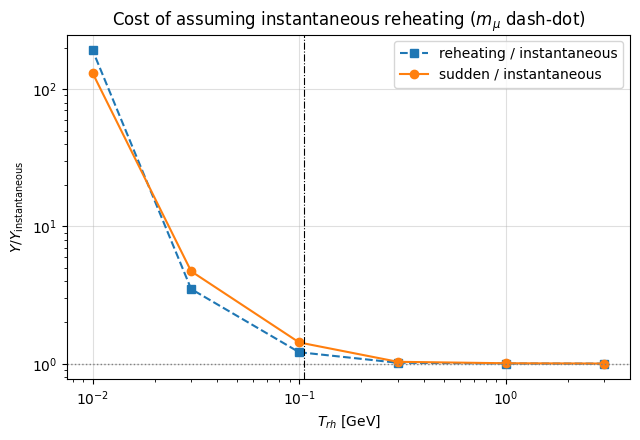

In [9]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.loglog(T_RH_CMP, Y_reh_c / Y_inst, "s--", label="reheating / instantaneous")
ax.loglog(T_RH_CMP, Y_sud_c / Y_inst, "o-", label="sudden / instantaneous")
ax.axhline(1.0, color="grey", lw=1.0, ls=":")
ax.axvline(M_MU, color="k", lw=0.8, ls="-.")
ax.set_xlabel(r"$T_{rh}$ [GeV]")
ax.set_ylabel(r"$Y / Y_{\rm instantaneous}$")
ax.set_title(r"Cost of assuming instantaneous reheating ($m_\mu$ dash-dot)")
ax.grid(alpha=0.4)
ax.legend()
fig.tight_layout()
plt.show()

Instantaneous is fine while $T_{rh}$ is above $m_\mu$, and then fails badly — by afactor of a few at $T_{rh} = 0.03$ GeV and by **two orders of magnitude** at$0.01$ GeV. It always errs the same way: it *underestimates*.The reason is visible in the `x_start` column. Instantaneous reheating at$T_{rh} = 0.01$ GeV begins the integration at $x = 10.6$, where the muons that sourcethe axions are Boltzmann suppressed by $e^{-10.6}$ — there is essentially nothing leftto produce from, so the run returns almost zero. The gradual treatment makes itsaxions during the reheating era, around $x \sim 1$ where production peaks, attemperatures well *above* $T_{rh}$, and then dilutes them. Diluted is still far morethan never produced.Note this flips the sign of the headline depending on what you compare against. Againsta universe with no reheating (section 2), an early matter era **suppresses** the relicby up to $10^4$. Against instantaneous reheating at the same $T_{rh}$, it **enhances**it by up to $\sim 200$. Both statements are true, and neither is the whole picture onits own — the baseline has to be stated.

## 3. DistributionsThe phase-space equation is expensive, so this uses a coarser grid than a productionrun and caches the results. The physics question is different from the yields: doesreheating change the *shape* of $f(q)$, or only its normalisation?

In [10]:
CACHE_DIR = "notebook_cache"
CACHE = os.path.join(CACHE_DIR, "distributions.npz")

N_X_FBE, N_Q_FBE = 150, 60
Q_FBE = np.linspace(1e-2, 20.0, N_Q_FBE)

# (label, background) -- solved in this order and stored under these keys.
CASES = [
    ("standard", None),
    ("sudden, T_rh=0.1", ("sudden", 0.1)),
    ("reheating, T_rh=0.1", ("reheating", 0.1)),
    ("sudden, T_rh=0.03", ("sudden", 0.03)),
    ("reheating, T_rh=0.03", ("reheating", 0.03)),
]


def make_background(spec):
    if spec is None:
        return StandardCosmology()
    kind, t_rh = spec
    if kind == "sudden":
        return SuddenDecayReheating(T_rh=t_rh)
    return PerturbativeReheating(T_rh=t_rh, T_start=T_START)


def solve_distribution(background):
    '''Final f(q) from the full phase-space equation.'''
    x = np.linspace(M_MU / T_START, 30.0, N_X_FBE)

    model = bz.Model(M_MU, 1e-10, 1.0, "b", background=background)
    model.changeGrid(x, Q_FBE)

    ann = LeptonAnnihilationToAxionMB(M_MU, G_MU, 1.0 / F_A, False)
    pri = PrimakoffScatteringMB(M_MU, G_MU, 1.0 / F_A, False)
    model.addCollisionTerm(ann.collisionTerm)
    model.addCollisionTerm(pri.collisionTerm)

    model.solve_fBE(np.zeros(N_Q_FBE), dict(fBE_LFC.SOLVER_OPTIONS))
    return model.getSolution()[-1, :], model.getDensity()[-1]


# Anything that changes the numbers goes in the key, so editing a grid size can never
# silently reload someone else's results.
CACHE_KEY = np.array([N_X_FBE, N_Q_FBE, F_A, T_START] + [t for _, s in CASES if s
                     for t in [s[1]]], dtype=float)

stored = np.load(CACHE) if os.path.exists(CACHE) else None
if stored is not None and (
    "key" not in stored or not np.array_equal(stored["key"], CACHE_KEY)
):
    print("cache was built with different parameters; recomputing")
    stored = None

if stored is not None:
    f_final = {label: stored[label] for label, _ in CASES}
    Y_fbe = {label: float(stored["Y_" + label]) for label, _ in CASES}
    print("loaded from", CACHE)
else:
    f_final, Y_fbe = {}, {}
    for label, spec in CASES:
        print("solving:", label, flush=True)
        f_final[label], Y_fbe[label] = solve_distribution(make_background(spec))
    os.makedirs(CACHE_DIR, exist_ok=True)
    payload = dict(f_final)
    payload.update({"Y_" + k: np.array(v) for k, v in Y_fbe.items()})
    payload["key"] = CACHE_KEY
    np.savez(CACHE, **payload)
    print("cached to", CACHE)

loaded from notebook_cache/distributions.npz


In [11]:
# The instantaneous runs start at T_rh rather than at T_START, so they need their own
# solves -- and their own cache, to avoid invalidating the expensive one above.
INSTANT_CACHE = os.path.join(CACHE_DIR, "distributions_instant.npz")
INSTANT_T_RH = [0.1, 0.03]
INSTANT_KEY = np.array([N_X_FBE, N_Q_FBE, F_A] + INSTANT_T_RH, dtype=float)


def solve_distribution_from(background, T_begin):
    '''Final f(q) for a run beginning at T_begin.'''
    x = np.linspace(M_MU / T_begin, 30.0, N_X_FBE)

    model = bz.Model(M_MU, 1e-10, 1.0, "b", background=background)
    model.changeGrid(x, Q_FBE)

    ann = LeptonAnnihilationToAxionMB(M_MU, G_MU, 1.0 / F_A, False)
    pri = PrimakoffScatteringMB(M_MU, G_MU, 1.0 / F_A, False)
    model.addCollisionTerm(ann.collisionTerm)
    model.addCollisionTerm(pri.collisionTerm)

    model.solve_fBE(np.zeros(N_Q_FBE), dict(fBE_LFC.SOLVER_OPTIONS))
    return model.getSolution()[-1, :], model.getDensity()[-1]


INSTANT_LABELS = ["instantaneous, T_rh={}".format(t) for t in INSTANT_T_RH]

cached = np.load(INSTANT_CACHE) if os.path.exists(INSTANT_CACHE) else None
if cached is not None and (
    "key" not in cached or not np.array_equal(cached["key"], INSTANT_KEY)
):
    cached = None

if cached is not None:
    for label in INSTANT_LABELS:
        f_final[label] = cached[label]
        Y_fbe[label] = float(cached["Y_" + label])
    print("loaded from", INSTANT_CACHE)
else:
    payload = {}
    for t_rh, label in zip(INSTANT_T_RH, INSTANT_LABELS):
        print("solving:", label, flush=True)
        f_final[label], Y_fbe[label] = solve_distribution_from(
            StandardCosmology(), t_rh)
        payload[label] = f_final[label]
        payload["Y_" + label] = np.array(Y_fbe[label])
    payload["key"] = INSTANT_KEY
    os.makedirs(CACHE_DIR, exist_ok=True)
    np.savez(INSTANT_CACHE, **payload)
    print("cached to", INSTANT_CACHE)

ALL_LABELS = [label for label, _ in CASES] + INSTANT_LABELS

loaded from notebook_cache/distributions_instant.npz


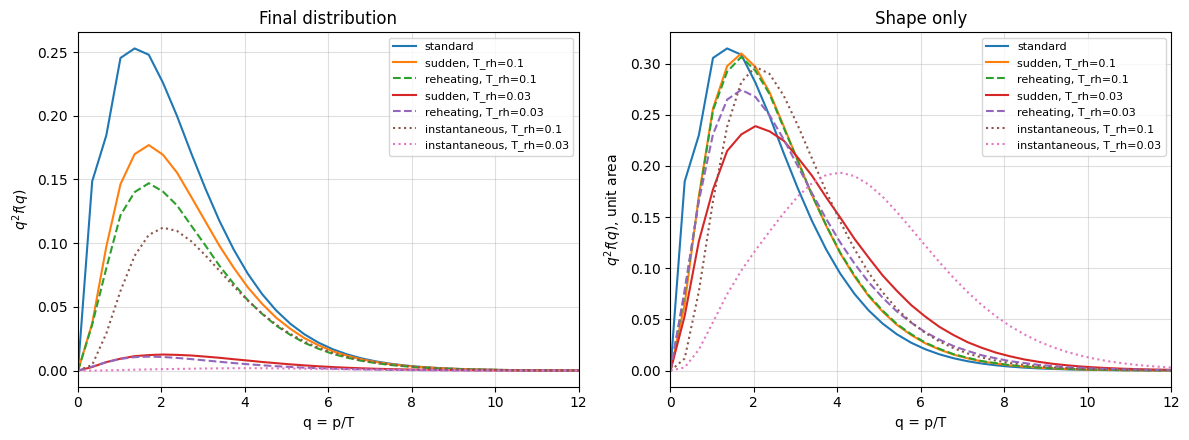

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for label in ALL_LABELS:
    if label.startswith("reheating"):
        style = "--"
    elif label.startswith("instantaneous"):
        style = ":"
    else:
        style = "-"
    axes[0].plot(Q_FBE, f_final[label], style, label=label)
    # Unit area, so only the shape is compared.
    norm = np.trapezoid(f_final[label], Q_FBE)
    axes[1].plot(Q_FBE, f_final[label] / norm, style, label=label)

axes[0].set_ylabel(r"$q^2 f(q)$")
axes[0].set_title("Final distribution")
axes[1].set_ylabel(r"$q^2 f(q)$, unit area")
axes[1].set_title("Shape only")

for ax in axes:
    ax.set_xlabel("q = p/T")
    ax.set_xlim(0, 12)
    ax.grid(alpha=0.4)
    ax.legend(fontsize=8)

fig.tight_layout()
plt.show()

In [13]:
print("{:>22} {:>13} {:>10} {:>9}".format("case", "Y (fBE)", "Y/Y_std", "<q>"))
for label in ALL_LABELS:
    mean_q = (np.trapezoid(Q_FBE * f_final[label], Q_FBE)
              / np.trapezoid(f_final[label], Q_FBE))
    print("{:>22} {:>13.5e} {:>10.4f} {:>9.3f}".format(
        label, Y_fbe[label], Y_fbe[label] / Y_fbe["standard"], mean_q))

                  case       Y (fBE)    Y/Y_std       <q>
              standard   8.63726e-03     1.0000     2.340
      sudden, T_rh=0.1   6.14152e-03     0.7111     2.619
   reheating, T_rh=0.1   5.15849e-03     0.5972     2.631
     sudden, T_rh=0.03   5.67992e-04     0.0658     3.198
  reheating, T_rh=0.03   4.29536e-04     0.0497     2.840
instantaneous, T_rh=0.1   4.06375e-03     0.4705     2.991
instantaneous, T_rh=0.03   1.04666e-04     0.0121     4.632


The left panel is dominated by the normalisation collapse already seen in the yields.The right panel is the interesting one: the spectra under reheating are **harder**,shifted to *higher* $q$, and $\langle q \rangle$ in the table quantifies it.That is worth pausing on, because it is the opposite of what the $(1-w)/w = 5/3$ termdoes on its own. That term drags each mode's $q$ *down*. The final spectrum is set bythe competition between it and *when* the population is produced, and the productiontiming wins:- Reheating suppresses early production, both through the faster $H$ and through the  entropy dumped on top of whatever was made. What survives is dominated by axions  produced *late*.- Late means $x \gg 1$, where the muons are non-relativistic and the axions come out  with $p \sim m_\mu/2$, so $q = p/T \sim x/2$ — large and growing.So the surviving population is weighted towards the hard, late-produced part of thespectrum, and that outruns the downward drag of the redshift term.The instantaneous curves are the clean test of that explanation, because they are theextreme case: they cannot produce anything before $T_{rh}$ at all, so *everything* ismade late. And they are by far the hardest spectra on the plot —$\langle q \rangle = 4.63$ at $T_{rh} = 0.03$ GeV, peaking out at $q \approx 4$ wherethe standard run peaks near $1.4$.Ordering $\langle q \rangle$ across the whole table sorts exactly by how late thesurviving population is made, which is what the mechanism predicts:    standard  <  reheating 0.1  <  reheating 0.03  <  sudden 0.03  <  instantaneousNote also that the two tiers disagree more in shape than in normalisation at$T_{rh} = 0.03$ GeV: about 13% in $\langle q \rangle$ against 35% in $Y$. If you careabout the spectrum, `sudden` is a worse approximation than the yield plot suggests.This matters for anything downstream that cares about the spectrum rather than thenumber: free-streaming, warmness constraints, and any $\Delta N_{\rm eff}$ estimateweighted by energy rather than number.

## 4. What to take away- **Yields** are suppressed once $T_{rh}$ falls into the production epoch, by four  orders of magnitude near the BBN floor. The mechanism is entropy dilution,  $d\ln(sa^3)/d\ln x = 5$, plus reduced production against a faster $H$.- **Distributions** come out *harder*, not softer. The momentum-redshift term grows  from $\tilde g \lesssim 0.3$ to $5/3$ and drags each mode down, but the shift in  *when* the surviving population is produced pushes the other way and wins.- **`sudden` versus `reheating`** agree to a fraction of a percent while the effect is  small and disagree by tens of percent where it is large, with the sign of the error  flipping. The cheap background is for scouting, not for numbers -- and it is worse  for the spectrum than the yield comparison alone would suggest.- **Instantaneous reheating underestimates**, by a factor of a few at  $T_{rh} = 0.03$ GeV and about $200$ at $0.01$ GeV, because it starts the integration  after the muons have already Boltzmann-suppressed away and so never makes the axions  at all. Resolving the reheating era is not a refinement here, it is the difference  between a population and nothing.- **State the baseline.** An early matter era suppresses the relic against a universe  that never had one, and enhances it against the instantaneous approximation at the  same $T_{rh}$. The two statements differ by six orders of magnitude and are both  correct.The remaining approximation on the low-$T_{rh}$ end is that the run starts on thereheating attractor rather than climbing the rising-temperature branch to $T_{max}$.That branch would make $x = m/T$ non-monotonic and needs both solvers re-expressed in$\ln a$.